# Scout scan failure modes by model

Load all `hle_failure_mode.parquet` outputs beneath `scans/` and plot the number of each primary failure mode for every evaluated model.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
def find_project_root(start: Path = Path.cwd()) -> Path:
    """Find the nearest parent containing the scans directory."""
    for candidate in (start, *start.parents):
        if (candidate / "scans").is_dir():
            return candidate
    raise FileNotFoundError("Could not find a scans directory in this path or its parents.")


project_root = find_project_root()
scan_dir = project_root / "scans"
result_files = sorted(scan_dir.glob("scan_id=*/hle_failure_mode.parquet"))

if not result_files:
    raise FileNotFoundError(f"No hle_failure_mode.parquet files found beneath {scan_dir}")

print(f"Found {len(result_files)} failure-mode result file(s).")
for result_file in result_files:
    print(f"- {result_file.relative_to(project_root)}")

Found 1 failure-mode result file(s).
- scans/scan_id=hzFshzFxALZCnN8SGmkGi7/hle_failure_mode.parquet


In [ ]:
columns = ["scan_id", "transcript_id", "transcript_model", "value", "scan_error"]
results = pd.concat(
    (pd.read_parquet(result_file, columns=columns) for result_file in result_files),
    ignore_index=True,
)

failure_modes = (
    results.loc[
        results["scan_error"].isna()
        & results["transcript_model"].notna()
        & results["value"].notna(),
        ["transcript_model", "value"],
    ]
    .rename(columns={"transcript_model": "model", "value": "failure_mode"})
)

if failure_modes.empty:
    raise ValueError("The scan files contain no successful failure-mode results to plot.")

counts = pd.crosstab(failure_modes["model"], failure_modes["failure_mode"])
counts = counts.loc[sorted(counts.index)]
counts = counts[counts.sum().sort_values(ascending=False).index]
counts

failure_mode,reasoning_failure,knowledge_failure,incorrect_reference_answer,ambiguous_or_defective_prompt,undetermined,judge_failure,resource_limit
model,,,,,,,
openrouter/openai/gpt-4o,114,41,22,16,2,0,0
openrouter/openai/gpt-5-mini,81,40,36,19,0,1,0
openrouter/openai/gpt-5.6-luna,57,29,41,20,4,1,1


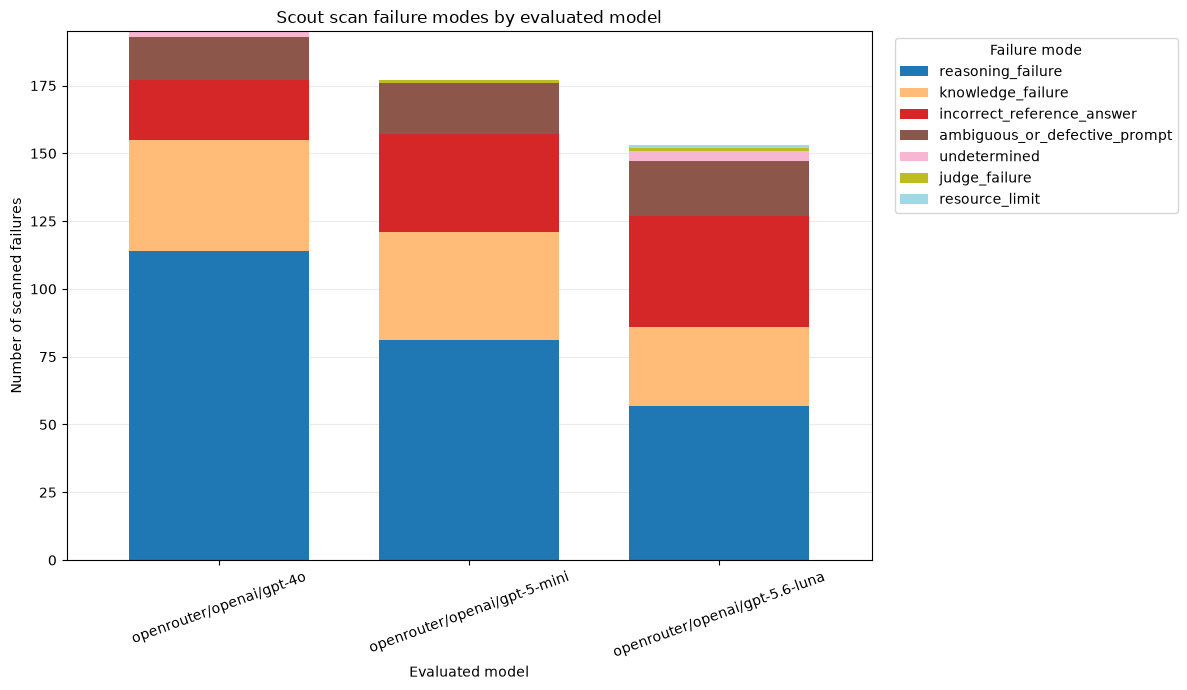

In [ ]:
ax = counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7),
    width=0.72,
    colormap="tab20",
)
ax.set_title("Scout scan failure modes by evaluated model")
ax.set_xlabel("Evaluated model")
ax.set_ylabel("Number of scanned failures")
ax.tick_params(axis="x", labelrotation=20)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(title="Failure mode", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()